# XAI 분석

1. XGBoost 학습
2. SHAP
3. Permutation Importance
4. Surrogate Tree (규칙 추출)
5. Counterfactual Explanation (이탈 방지 액션)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import xgboost as xgb
import shap

BASE = Path('..').resolve()
SEED = 42

df = pd.read_csv(
    BASE / '_data/02_interim/260510_features/Membership_features_clean.csv',
    encoding='utf-8-sig'
)
print(f'shape: {df.shape}')
df.head(3)

shape: (23343, 81)


,USER_KEY,product_code,price,billing_method,is_churn_prevented,payment_device,is_user_verified,gender,age,is_repurchase,...,family_ratio,drama_ratio,action_ratio,thriller_ratio,sf_ratio,comedy_ratio,romance_ratio,action_sf_thriller_affinity,family_content_affinity,genre_entropy_norm
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,0,pc,1,F,20.0,1,...,0.0769,0.2308,0.3077,0.2308,0.0,0.0,0.0769,1.0,0.0,0.9105
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1,pc,1,F,25.0,0,...,0.0000,0.3333,0.6667,0.0000,0.0,0.0,0.0000,1.0,0.0,0.9183
2,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.0,180,0,android,1,F,20.0,0,...,0.0000,0.0000,0.0000,0.5000,0.0,0.5,0.0000,1.0,0.0,1.0000


In [2]:
EXCLUDE = [
    'USER_KEY','product_code','payment_device','device_group',
    'gender','age_group','is_repurchase'
]
EXCLUDE = [c for c in EXCLUDE if c in df.columns]

for col in df.select_dtypes(include='object').columns:
    if col not in EXCLUDE:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

FEATURES = [c for c in df.columns if c not in EXCLUDE]
X = df[FEATURES].fillna(0)
y = df['is_repurchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
spw = (y_train==0).sum() / (y_train==1).sum()

model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'F1:      {f1_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=['이탈(0)','재구매(1)']))

AUC-ROC: 0.8826
F1:      0.8582
              precision    recall  f1-score   support

       이탈(0)       0.63      0.77      0.69      1328
      재구매(1)       0.90      0.82      0.86      3341

    accuracy                           0.81      4669
   macro avg       0.77      0.80      0.78      4669
weighted avg       0.82      0.81      0.81      4669



## 1. SHAP

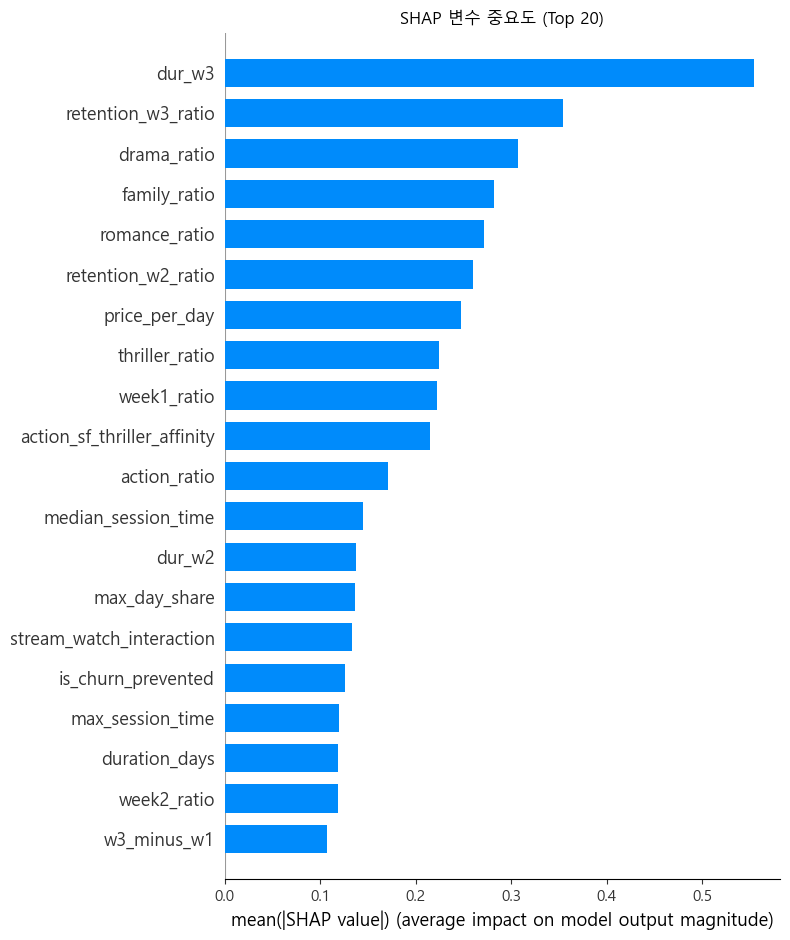

In [3]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10,9))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=20)
plt.title('SHAP 변수 중요도 (Top 20)')
plt.tight_layout()
plt.show()

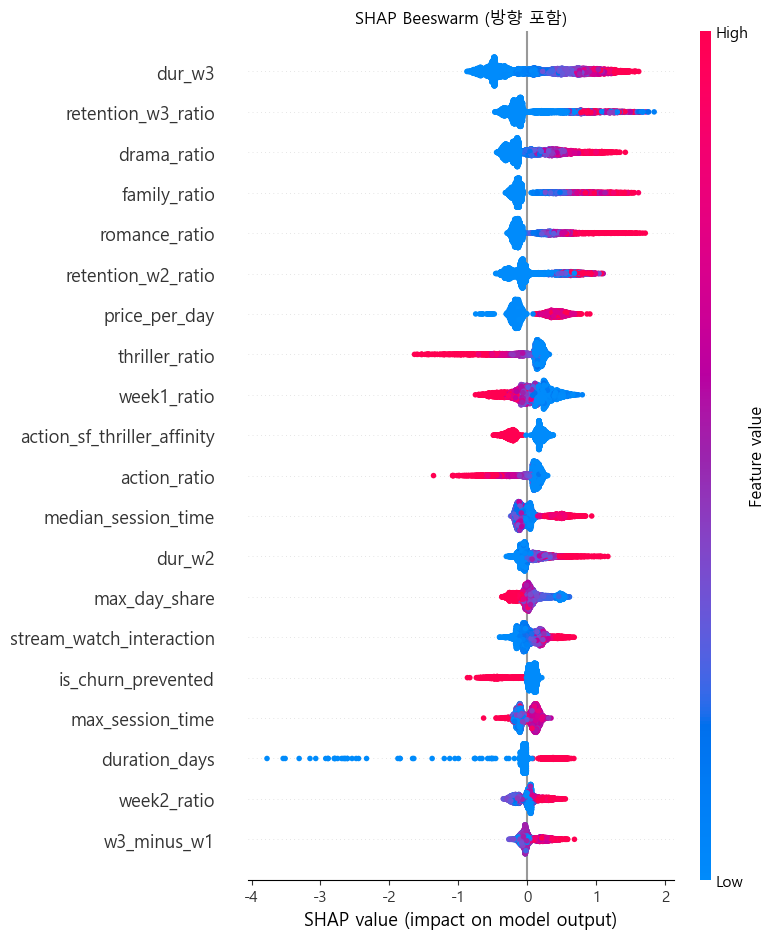

                             변수      SHAP
1                        dur_w3  0.553625
2            retention_w3_ratio  0.354276
3                   drama_ratio  0.307422
4                  family_ratio  0.281478
5                 romance_ratio  0.270995
6            retention_w2_ratio  0.260190
7                 price_per_day  0.247479
8                thriller_ratio  0.224479
9                   week1_ratio  0.222495
10  action_sf_thriller_affinity  0.214744
11                 action_ratio  0.171360
12          median_session_time  0.144738
13                       dur_w2  0.137604
14                max_day_share  0.136539
15     stream_watch_interaction  0.132967
16           is_churn_prevented  0.125956
17             max_session_time  0.119970
18                duration_days  0.118992
19                  week2_ratio  0.118707
20                  w3_minus_w1  0.107171


In [4]:
plt.figure(figsize=(10,9))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title('SHAP Beeswarm (방향 포함)')
plt.tight_layout()
plt.show()

# 중요도 테이블
shap_df = pd.DataFrame({
    '변수': FEATURES,
    'SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP', ascending=False).reset_index(drop=True)
shap_df.index += 1
print(shap_df.head(20).to_string())

## 2. Permutation Importance

=== Permutation Importance (AUC 감소량) ===
                             변수  AUC감소(평균)      표준편차
1                        dur_w3   0.032729  0.002261
2            retention_w3_ratio   0.023965  0.002777
3                   drama_ratio   0.012712  0.000928
4                  family_ratio   0.012569  0.001180
5            retention_w2_ratio   0.011881  0.001395
6                 romance_ratio   0.010243  0.000903
7                thriller_ratio   0.009266  0.000936
8                   week1_ratio   0.009182  0.001013
9                 max_day_share   0.007665  0.000524
10                price_per_day   0.006424  0.001307
11  action_sf_thriller_affinity   0.005209  0.000522
12                duration_days   0.004960  0.000872
13          median_session_time   0.004868  0.000636
14                  week2_ratio   0.004285  0.000554
15                       dur_w2   0.003976  0.000901
16                 action_ratio   0.003836  0.000580
17                      recency   0.002721  0.000383
18   

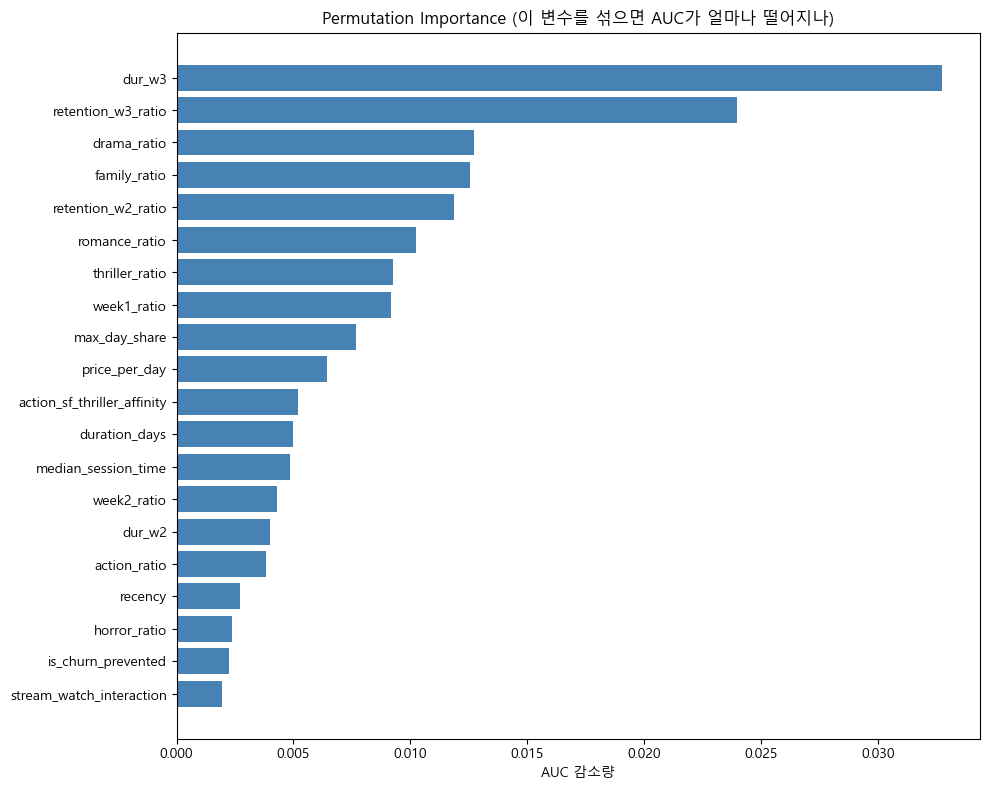

In [5]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10, random_state=SEED,
    scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    '변수': FEATURES,
    'AUC감소(평균)': perm.importances_mean,
    '표준편차': perm.importances_std,
}).sort_values('AUC감소(평균)', ascending=False).reset_index(drop=True)
perm_df.index += 1

print('=== Permutation Importance (AUC 감소량) ===')
print(perm_df.head(20).to_string())

fig, ax = plt.subplots(figsize=(10,8))
top20 = perm_df.head(20)
ax.barh(top20['변수'][::-1], top20['AUC감소(평균)'][::-1], color='steelblue')
ax.set_title('Permutation Importance (이 변수를 섞으면 AUC가 얼마나 떨어지나)')
ax.set_xlabel('AUC 감소량')
plt.tight_layout()
plt.show()

## 3. Surrogate Tree (규칙 추출)

복잡한 XGBoost를 얕은 Decision Tree로 근사 → 이탈 규칙을 사람이 읽을 수 있게 변환

In [6]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# XGBoost 예측값을 타겟으로 얕은 트리 학습
y_pred_proba_train = model.predict_proba(X_train)[:,1]

surrogate = DecisionTreeClassifier(max_depth=4, random_state=SEED)
surrogate.fit(X_train, (y_pred_proba_train > 0.5).astype(int))

print('=== Surrogate Tree 규칙 ===')
print(export_text(surrogate, feature_names=FEATURES, max_depth=4))

=== Surrogate Tree 규칙 ===
|--- dur_w3 <= 3.50
|   |--- dur_w2 <= 62.50
|   |   |--- week1_ratio <= 0.36
|   |   |   |--- price_per_day <= 13.89
|   |   |   |   |--- class: 0
|   |   |   |--- price_per_day >  13.89
|   |   |   |   |--- class: 1
|   |   |--- week1_ratio >  0.36
|   |   |   |--- week3_ratio <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- week3_ratio >  0.00
|   |   |   |   |--- class: 0
|   |--- dur_w2 >  62.50
|   |   |--- retention_w2_ratio <= 2.05
|   |   |   |--- action_sf_thriller_affinity <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- action_sf_thriller_affinity >  0.50
|   |   |   |   |--- class: 0
|   |   |--- retention_w2_ratio >  2.05
|   |   |   |--- action_sf_thriller_affinity <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- action_sf_thriller_affinity >  0.50
|   |   |   |   |--- class: 1
|--- dur_w3 >  3.50
|   |--- action_sf_thriller_affinity <= 0.50
|   |   |--- horror_ratio <= 0.23
|   |   |   |--- dur_w3 <= 96.50
|   |   |   |   |---

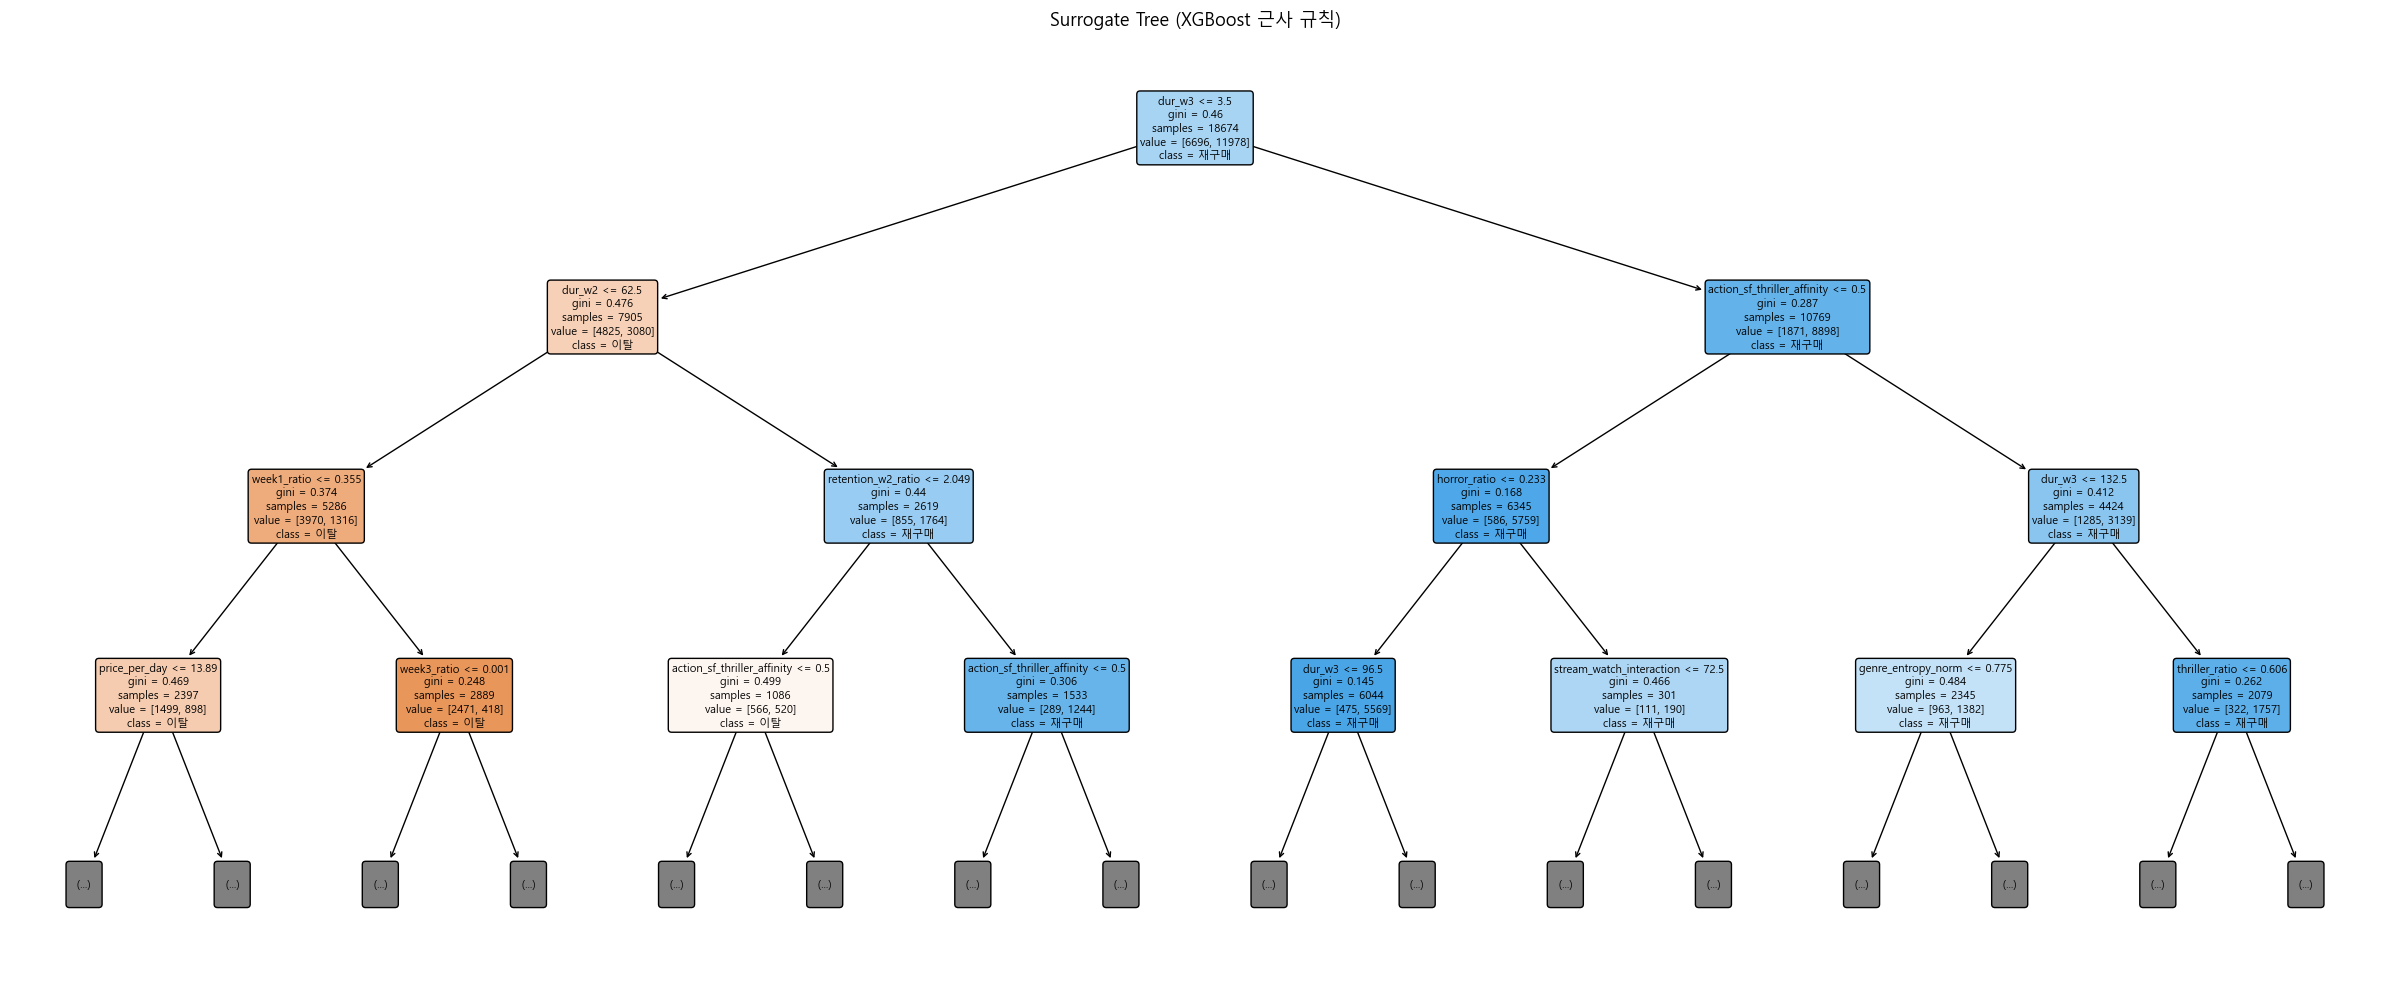

In [7]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(surrogate, feature_names=FEATURES, class_names=['이탈','재구매'],
          filled=True, rounded=True, ax=ax, max_depth=3, fontsize=8)
plt.title('Surrogate Tree (XGBoost 근사 규칙)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Counterfactual Explanation

"이 고객이 무엇을 바꾸면 재구매 가능성이 높아지는가?"

In [8]:
# 이탈 예측 고위험 고객 선택
y_pred_test = model.predict_proba(X_test)[:,1]
churn_mask  = (y_pred_test < 0.4) & (y_test.values == 0)  # 이탈 예측 + 실제 이탈
churn_idx   = np.where(churn_mask)[0]

# 가장 확신도 높은 이탈 고객 1명
top_churn_idx = churn_idx[np.argsort(y_pred_test[churn_idx])[0]]
churn_user    = X_test.iloc[top_churn_idx]

print(f'선택된 이탈 고객 재구매 확률: {y_pred_test[top_churn_idx]:.1%}')
print()
print('=== 주요 특성 ===')
key_cols = ['duration_days','recency','dur_w1','dur_w2','dur_w3',
            'cold_start','avg_session_time','active_days']
for c in key_cols:
    if c in churn_user.index:
        print(f'  {c}: {churn_user[c]}')

선택된 이탈 고객 재구매 확률: 0.2%

=== 주요 특성 ===
  duration_days: 0.0
  recency: 18.0
  dur_w1: 27.0
  dur_w2: 0.0
  dur_w3: 0.0
  cold_start: 1.0
  avg_session_time: 9.0
  active_days: 1.0


=== Counterfactual: 어떤 행동이 재구매 확률을 높이는가? ===
                변경 변수  변경 값  원래 재구매확률  변경 후 재구매확률  확률 변화
               dur_w3 300.0     0.002       0.009  0.007
          active_days  15.0     0.002       0.003  0.001
     avg_session_time  60.0     0.002       0.003  0.001
               dur_w2 200.0     0.002       0.003  0.001
           cold_start   1.0     0.002       0.002  0.000
vh_last7d_watch_ratio   0.5     0.002       0.002 -0.000
              recency   1.0     0.002       0.001 -0.001


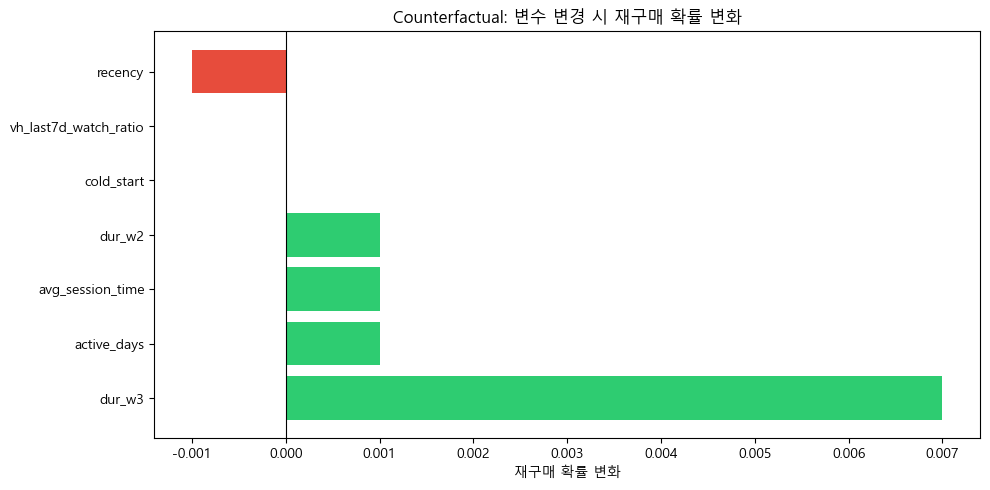

In [9]:
# Counterfactual: 변수 하나씩 바꿔서 재구매 확률 변화 확인
results = []
base_prob = model.predict_proba(churn_user.values.reshape(1,-1))[0,1]

for feat, new_val in [
    ('recency',          1),    # 종료일 직전까지 시청
    ('dur_w3',         300),    # 3주차 시청 증가
    ('active_days',     15),    # 활동일 증가
    ('avg_session_time', 60),   # 평균 시청 시간 증가
    ('cold_start',        1),   # 7일 내 첫 시청
    ('dur_w2',          200),   # 2주차 시청 증가
    ('vh_last7d_watch_ratio', 0.5),  # 마지막 7일 시청 집중
]:
    if feat not in churn_user.index:
        continue
    cf_user = churn_user.copy()
    cf_user[feat] = new_val
    cf_prob = model.predict_proba(cf_user.values.reshape(1,-1))[0,1]
    results.append({
        '변경 변수': feat,
        '변경 값': new_val,
        '원래 재구매확률': round(base_prob, 3),
        '변경 후 재구매확률': round(cf_prob, 3),
        '확률 변화': round(cf_prob - base_prob, 3)
    })

cf_df = pd.DataFrame(results).sort_values('확률 변화', ascending=False)
print('=== Counterfactual: 어떤 행동이 재구매 확률을 높이는가? ===')
print(cf_df.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(10,5))
colors = ['#2ecc71' if v>0 else '#e74c3c' for v in cf_df['확률 변화']]
ax.barh(cf_df['변경 변수'], cf_df['확률 변화'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Counterfactual: 변수 변경 시 재구매 확률 변화')
ax.set_xlabel('재구매 확률 변화')
plt.tight_layout()
plt.show()